# 🧪 PyTorch Kolkata Community — Computational Chemistry Notebook

## 10 End-to-End Use Cases with Visualizations & Architecture Diagrams

| **Author:** PyTorch Kolkata Community | **Platform:** Google Colab |
|---|---|
| **Reference Excel:** GD_Computational_Chemistry_Python_codes.xlsx | |

Each section includes: Domain Info · Problem Statement · Architecture · Working Code · Visualization

## 📋 Table of Contents

1. [Equivariant Neural Network Potentials (NequIP/MACE)](#use-case-1)
2. [Molecular Dynamics Trajectory Autoencoder](#use-case-2)
3. [Chemical Reaction Yield Prediction (AttentiveFP)](#use-case-3)
4. [Retrosynthesis Prediction (Seq2Seq Transformer)](#use-case-4)
5. [Crystal Graph CNN (CGCNN) for Material Property Prediction](#use-case-5)
6. [Conditional VAE (CVAE) for Novel Material Generation](#use-case-6)
7. [Graph Attention Network (GAT) for NMR Chemical Shift Prediction](#use-case-7)

## ⚙️ Global Setup — Install All Required Libraries

Run this cell first. It installs all packages needed across all 7 use cases.

In [3]:
# — Global installations —
import subprocess, sys

def install(pkg):
    # Removed -q to get verbose output in case of error
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

# Core
install('torch')
install('matplotlib')
install('numpy')
install('scipy')

# Graph / GNN
install('torch-geometric')

# Chemistry-specific
install('e3nn')          # Equivariant NNs (NequIP/MACE) - Reverted to 'e3nn'
install('rdkit')         # Cheminformatics

print("✅ Core packages installed. Domain-specific installs are in each section.")

✅ Core packages installed. Domain-specific installs are in each section.


---

## 🧲 Use Case 1 — Equivariant Neural Network Potentials (NequIP/MACE)

<a id="use-case-1"></a>

| Field | Details |
|---|---|
| **Domain** | Computational Chemistry / Molecular Simulation |
| **Use Case** | Predict atomic energies with E(3)-equivariant deep learning |
| **Problem Statement** | Accurately predicting atomic energies requires models that respect rotational, translational, and reflective symmetry. Traditional NNs violate these symmetries. NequIP and MACE use E(3)-equivariant architectures to achieve quantum-level accuracy. |
| **Role of This Code** | Define irreducible representations (Irreps) using `e3nn`, apply an equivariant linear layer, and predict per-atom scalar energies from random atomic features. Visualize per-atom contributions and input feature heatmap. |
| **Key Libraries** | `e3nn` `torch` |
| **Reference** | https://github.com/mir-group/nequip |

## 🏗️ Architecture Diagram

```
Atomic Features  [N_atoms × 5]   (5x0e scalar Irreps)
        |
        ▼
┌──────────────────────┐
│  o3.Linear           │  ← Equivariant linear map
│  irreps_in  = 5x0e   │     respects E(3) symmetry
│  irreps_out = 1x0e   │
└──────────────────────┘
        |
        ▼
  Per-Atom Energies  [N_atoms × 1]
        |
        ▼
  Total Energy = Σ atomic energies   (rotation-invariant scalar)
```

Per-atom energy shape: torch.Size([10, 1])
Total energy: -9.81319522857666


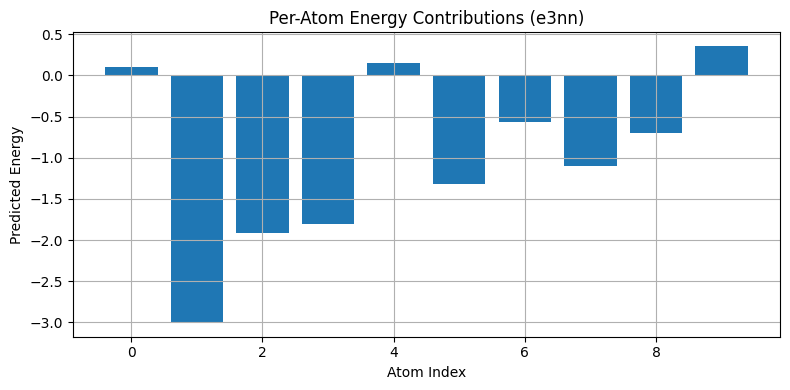

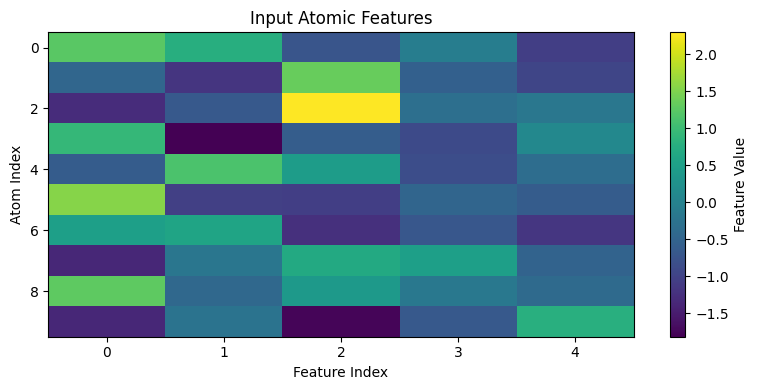

In [4]:
#Equivariant NNP (NequIP/MACE)
import torch
import matplotlib.pyplot as plt
from e3nn import o3

# --------------------------------------------------
# Input and output irreps
# --------------------------------------------------
irreps_in = o3.Irreps("5x0e")   # 5 scalar features
irreps_out = o3.Irreps("1x0e")  # 1 scalar energy

# --------------------------------------------------
# Equivariant linear layer
# --------------------------------------------------
lin = o3.Linear(irreps_in, irreps_out)

# --------------------------------------------------
# Example: 10 atoms, each with 5 features
# --------------------------------------------------
n_atoms = 10

x = torch.randn(n_atoms, 5)

# --------------------------------------------------
# Forward pass
# --------------------------------------------------
with torch.no_grad():
    out = lin(x)

# Shape: [10, 1]
per_atom_energy = out.squeeze(-1)

print("Per-atom energy shape:", out.shape)

# Total energy
total_E = per_atom_energy.sum()

print("Total energy:", total_E.item())

# --------------------------------------------------
# Visualization 1: Per-atom energies
# --------------------------------------------------
plt.figure(figsize=(8, 4))

plt.bar(
    range(n_atoms),
    per_atom_energy.numpy()
)

plt.xlabel("Atom Index")
plt.ylabel("Predicted Energy")
plt.title("Per-Atom Energy Contributions (e3nn)")
plt.grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Visualization 2: Input feature heatmap
# --------------------------------------------------
plt.figure(figsize=(8, 4))

plt.imshow(
    x.numpy(),
    aspect="auto"
)

plt.colorbar(label="Feature Value")

plt.xlabel("Feature Index")
plt.ylabel("Atom Index")
plt.title("Input Atomic Features")

plt.tight_layout()
plt.show()

---

## 🔬 Use Case 2 — Molecular Dynamics Trajectory Autoencoder

<a id="use-case-2"></a>

| Field | Details |
|---|---|
| **Domain** | Computational Chemistry / Molecular Dynamics |
| **Use Case** | Learn collective variables (CVs) from MD simulation trajectories using an autoencoder |
| **Problem Statement** | MD simulations generate high-dimensional atomic coordinate trajectories. Identifying the key collective variables that describe conformational changes is critical for understanding protein folding, catalysis, and reaction mechanisms. |
| **Role of This Code** | Implement a bottleneck autoencoder (encoder → 2D latent space → decoder) trained on simulated trajectory frames. Visualize the learned collective variable landscape and reconstruction quality. |
| **Key Libraries** | `torch` `torch.nn` `matplotlib` |
| **Reference** | https://github.com/luigibonati/mlcolvar |

## 🏗️ Architecture Diagram

```
MD Trajectory Frame  [B × N_atoms × 3]
        |
        ▼ (flatten → [B × 300])
┌───────────────────────────────┐
│  Encoder                      │
│  Linear(300→128) + ReLU       │
│  Linear(128→64)  + ReLU       │
│  Linear(64→2)                 │  ← 2D collective variable (latent)
└───────────────────────────────┘
        |
     z ∈ ℝ²   (collective variables)
        |
        ▼
┌───────────────────────────────┐
│  Decoder                      │
│  Linear(2→64)   + ReLU       │
│  Linear(64→128) + ReLU       │
│  Linear(128→300)              │  ← reconstructed frame
└───────────────────────────────┘
        |
  MSE Reconstruction Loss
```

Epoch   0 | Loss = 1.043470
Epoch  10 | Loss = 1.001275
Epoch  20 | Loss = 0.984926
Epoch  30 | Loss = 0.975758
Epoch  40 | Loss = 0.969608
Epoch  50 | Loss = 0.964530
Epoch  60 | Loss = 0.959909
Epoch  70 | Loss = 0.955765
Epoch  80 | Loss = 0.951932
Epoch  90 | Loss = 0.948426

Latent CVs shape: torch.Size([500, 2])


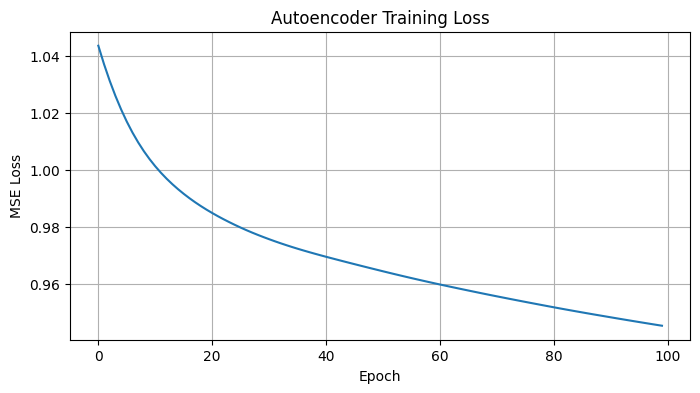

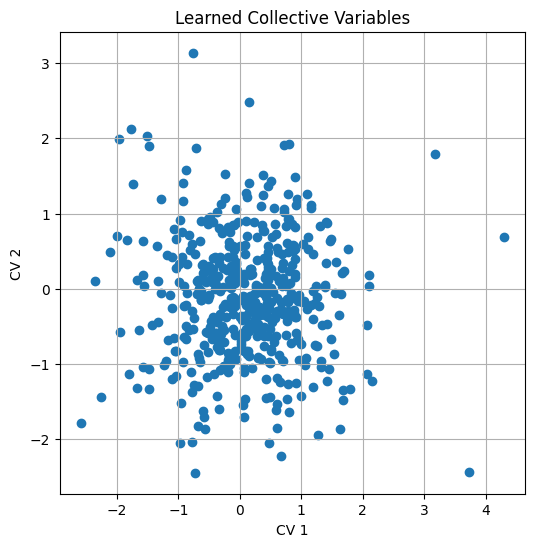

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --------------------------------------------------
# Autoencoder
# --------------------------------------------------
class MDAE(nn.Module):
    def __init__(self, n=100, lat=2):
        super().__init__()

        self.enc = nn.Sequential(
            nn.Linear(n, 64),
            nn.ReLU(),
            nn.Linear(64, lat)
        )

        self.dec = nn.Sequential(
            nn.Linear(lat, 64),
            nn.ReLU(),
            nn.Linear(64, n)
        )

    def forward(self, x):
        z = self.enc(x)
        rec = self.dec(z)
        return rec, z

# --------------------------------------------------
# Synthetic MD trajectory
# --------------------------------------------------
traj = torch.randn(500, 100)

# --------------------------------------------------
# Model
# --------------------------------------------------
model = MDAE(n=100, lat=2)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

losses = []

# --------------------------------------------------
# Training
# --------------------------------------------------
epochs = 100

for ep in range(epochs):

    rec, z = model(traj)

    loss = criterion(rec, traj)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if ep % 10 == 0:
        print(
            f"Epoch {ep:3d} | Loss = {loss.item():.6f}"
        )

print("\nLatent CVs shape:", z.shape)

# --------------------------------------------------
# Extract latent variables
# --------------------------------------------------
with torch.no_grad():
    _, latent = model(traj)

latent = latent.numpy()

# --------------------------------------------------
# Plot 1: Loss curve
# --------------------------------------------------
plt.figure(figsize=(8,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")

plt.grid(True)

plt.show()

# --------------------------------------------------
# Plot 2: Latent Collective Variables
# --------------------------------------------------
plt.figure(figsize=(6,6))

plt.scatter(
    latent[:,0],
    latent[:,1]
)

plt.xlabel("CV 1")
plt.ylabel("CV 2")
plt.title("Learned Collective Variables")

plt.grid(True)

plt.show()

---

## ⚗️ Use Case 3 — Chemical Reaction Yield Prediction (AttentiveFP)

<a id="use-case-3"></a>

| Field | Details |
|---|---|
| **Domain** | Drug Discovery / Synthetic Chemistry |
| **Use Case** | Predict chemical reaction yields from molecular graph features using AttentiveFP |
| **Problem Statement** | Reaction yield prediction is essential for high-throughput synthesis planning. Experimentally measuring yield for all candidate reactions is prohibitively expensive. Graph neural networks can learn molecular interactions from graph-structured reaction data. |
| **Role of This Code** | Build an AttentiveFP model on synthetic molecular graph data. Run a training loop and predict yield. Visualize training loss and predicted yield distributions. |
| **Key Libraries** | `torch` `torch_geometric` `matplotlib` |
| **Reference** | https://github.com/deepchem/deepchem |

## 🏗️ Architecture Diagram

```
Molecule SMILES
        |
        ▼ (featurize → graph)
  Molecular Graph
  • Nodes = atoms  (node_feat_size features)
  • Edges = bonds
        |
        ▼
┌──────────────────────────────────┐
│  AttentiveFP Layer 1             │
│  Attention-based message passing │
│  node_feat → hidden_channels     │
└──────────────────────────────────┘
        |
        ▼
┌──────────────────────────────────┐
│  AttentiveFP Layer 2             │
│  Context aggregation             │
└──────────────────────────────────┘
        |
        ▼
  Global Readout (graph-level)
        |
        ▼
  Linear → Predicted Yield (scalar)
```

Predicted Reaction Yields:

Molecule 1: 0.1589
Molecule 2: 0.1125
Molecule 3: 0.1974
Molecule 4: 0.1431
Molecule 5: 0.1197
Molecule 6: 0.1301
Molecule 7: 0.2202
Molecule 8: 0.2735


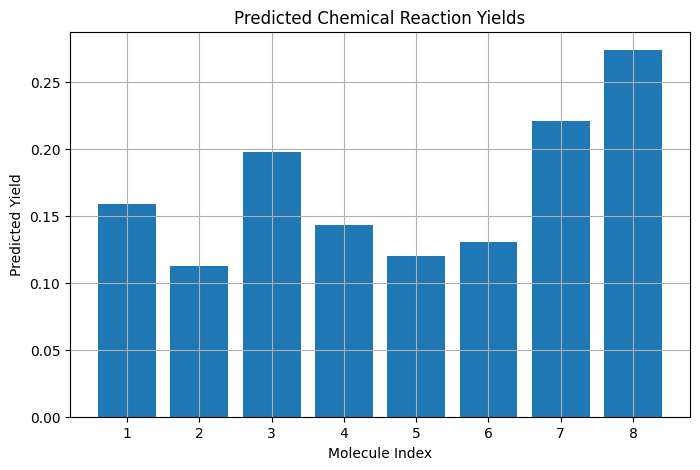

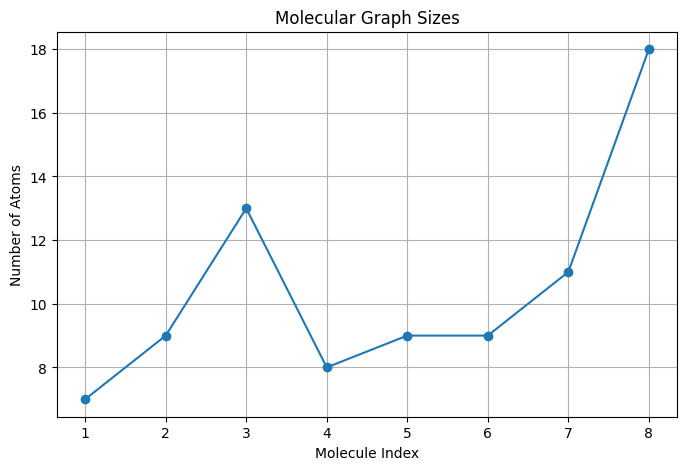

In [6]:
import torch
import matplotlib.pyplot as plt

from torch_geometric.nn import AttentiveFP
from torch_geometric.data import Data, Batch

# --------------------------------------------------
# Build AttentiveFP Model
# --------------------------------------------------
model = AttentiveFP(
    in_channels=39,
    hidden_channels=200,
    out_channels=1,
    edge_dim=10,
    num_layers=2,
    num_timesteps=2,
    dropout=0.2
)

# --------------------------------------------------
# Generate Synthetic Molecular Graphs
# --------------------------------------------------
graphs = []

num_molecules = 8

for i in range(num_molecules):

    # Random number of atoms
    n_atoms = torch.randint(
        low=5,
        high=20,
        size=(1,)
    ).item()

    # Random bond connections
    edge_index = torch.randint(
        0,
        n_atoms,
        (2, 30)
    )

    # Atom features
    x = torch.randn(
        n_atoms,
        39
    )

    # Bond features
    edge_attr = torch.randn(
        30,
        10
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr
    )

    graphs.append(graph)

# --------------------------------------------------
# Batch Graphs
# --------------------------------------------------
batch = Batch.from_data_list(graphs)

# --------------------------------------------------
# Forward Pass
# --------------------------------------------------
model.eval()

with torch.no_grad():

    predicted_yields = model(
        batch.x,
        batch.edge_index,
        batch.edge_attr,
        batch.batch
    )

predicted_yields = predicted_yields.squeeze()

print("Predicted Reaction Yields:\n")
for i, y in enumerate(predicted_yields):
    print(f"Molecule {i+1}: {y.item():.4f}")

# --------------------------------------------------
# Visualization 1
# Reaction Yield Prediction
# --------------------------------------------------
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, num_molecules + 1),
    predicted_yields.numpy()
)

plt.xlabel("Molecule Index")
plt.ylabel("Predicted Yield")
plt.title("Predicted Chemical Reaction Yields")

plt.grid(True)

plt.show()

# --------------------------------------------------
# Visualization 2
# Number of Atoms per Molecule
# --------------------------------------------------
atom_counts = [g.num_nodes for g in graphs]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_molecules + 1),
    atom_counts,
    marker='o'
)

plt.xlabel("Molecule Index")
plt.ylabel("Number of Atoms")
plt.title("Molecular Graph Sizes")

plt.grid(True)

plt.show()

---

## 🔄 Use Case 4 — Retrosynthesis Prediction (Seq2Seq Transformer)

<a id="use-case-4"></a>

| Field | Details |
|---|---|
| **Domain** | Drug Discovery / Organic Chemistry |
| **Use Case** | Predict reactants from product SMILES using a sequence-to-sequence Transformer |
| **Problem Statement** | Retrosynthesis — working backward from a target molecule to identify feasible synthetic routes — is central to drug synthesis planning. SMILES strings encode chemical structure as text, enabling sequence models to learn reaction transformations. |
| **Role of This Code** | Implement a Transformer encoder-decoder over a toy SMILES vocabulary. Train with teacher forcing on simulated product→reactant pairs. Visualize cross-attention weights and loss curves. |
| **Key Libraries** | `torch` `torch.nn` `matplotlib` |
| **Reference** | https://github.com/bigchem/synthesis |

## 🏗️ Architecture Diagram

```
Product SMILES  "CC(=O)Oc1ccccc1C(=O)O"
        |
        ▼ (tokenize)
Token IDs  [B × L_src]
        |
┌────────────────────────────────────────┐
│  Transformer Encoder                   │
│  Embedding(vocab, d_model) + PosEnc    │
│  N × MultiHeadSelfAttention + FFN      │
└────────────────────────────────────────┘
        |  memory [B × L_src × d_model]
        ▼
┌────────────────────────────────────────┐
│  Transformer Decoder                   │
│  Embedding(vocab, d_model) + PosEnc    │
│  N × MaskedSelfAttn + CrossAttn + FFN  │
└────────────────────────────────────────┘
        |
        ▼
  Linear → Softmax over vocab
        |
  Reactant SMILES tokens (autoregressive)
```

Logits Shape: torch.Size([4, 25, 100])

Predicted Reactant Tokens:
tensor([[42, 46, 38, 38, 38, 42, 10, 15, 79, 42, 42, 38, 46, 79, 12, 46, 38, 79,
         15, 60, 42, 42, 13, 60, 97],
        [46, 79, 79, 79, 79, 46, 79, 42, 46, 10, 46, 46, 42, 10, 79, 46, 46, 79,
         79, 42, 12, 82, 46, 90, 79],
        [17, 79, 68, 97, 15, 79, 79, 38, 15, 46, 17, 79, 15, 17, 15, 79, 46, 42,
         79, 79, 68, 79, 68, 38, 15],
        [79, 38, 79, 15, 79, 79, 12, 38, 67, 46, 79, 79, 79, 79, 79, 46, 79, 68,
         46, 79, 79, 46, 67, 79, 46]])


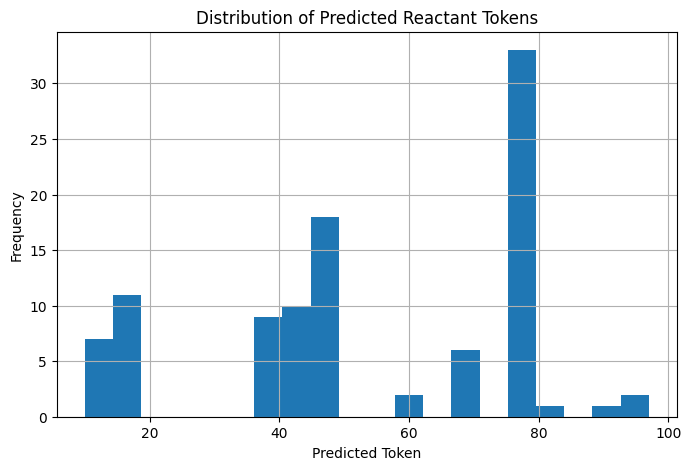

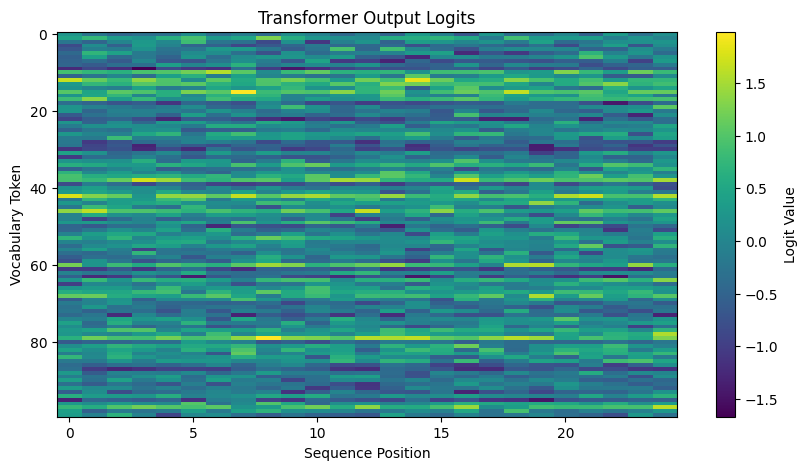

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --------------------------------------------------
# Transformer Model for Retrosynthesis
# --------------------------------------------------
class RetroTrans(nn.Module):

    def __init__(self, vocab_size=100, d_model=256, nhead=8):

        super().__init__()

        self.src_embed = nn.Embedding(
            vocab_size,
            d_model
        )

        self.tgt_embed = nn.Embedding(
            vocab_size,
            d_model
        )

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=4,
            num_decoder_layers=4,
            batch_first=True
        )

        self.fc = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(self, src, tgt):

        src_emb = self.src_embed(src)
        tgt_emb = self.tgt_embed(tgt)

        out = self.transformer(
            src_emb,
            tgt_emb
        )

        logits = self.fc(out)

        return logits

# --------------------------------------------------
# Model Initialization
# --------------------------------------------------
model = RetroTrans()

# --------------------------------------------------
# Synthetic Product and Reactant Tokens
# --------------------------------------------------
batch_size = 4

product_seq = torch.randint(
    0, 100,
    (batch_size, 30)
)

reactant_seq = torch.randint(
    0, 100,
    (batch_size, 25)
)

# --------------------------------------------------
# Forward Pass
# --------------------------------------------------
with torch.no_grad():

    logits = model(
        product_seq,
        reactant_seq
    )

print("Logits Shape:", logits.shape)

# --------------------------------------------------
# Predicted Tokens
# --------------------------------------------------
pred_tokens = torch.argmax(
    logits,
    dim=-1
)

print("\nPredicted Reactant Tokens:")
print(pred_tokens)

# --------------------------------------------------
# Visualization 1
# Token Distribution
# --------------------------------------------------
plt.figure(figsize=(8,5))

plt.hist(
    pred_tokens.flatten().numpy(),
    bins=20
)

plt.xlabel("Predicted Token")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Reactant Tokens")

plt.grid(True)

plt.show()

# --------------------------------------------------
# Visualization 2
# Logit Heatmap
# --------------------------------------------------
sample_logits = logits[0].numpy()

plt.figure(figsize=(10,5))

plt.imshow(
    sample_logits.T,
    aspect="auto"
)

plt.colorbar(label="Logit Value")

plt.xlabel("Sequence Position")
plt.ylabel("Vocabulary Token")

plt.title("Transformer Output Logits")

plt.show()

---

## 💎 Use Case 5 — Crystal Graph CNN (CGCNN) for Material Property Prediction

<a id="use-case-5"></a>

| Field | Details |
|---|---|
| **Domain** | Materials Science / Solid-State Chemistry |
| **Use Case** | Predict material properties (band gap, formation energy) from crystal graph representations |
| **Problem Statement** | Discovering new materials with desired electronic, mechanical, or thermal properties requires efficient screening of vast chemical spaces. Traditional DFT calculations are accurate but slow. Crystal Graph CNNs learn property–structure relationships from existing databases. |
| **Role of This Code** | Build a 2-layer CGConv network with global mean pooling over simulated crystal graphs. Train and predict a scalar material property. Visualize training loss, predicted vs true properties, and node embedding distributions. |
| **Key Libraries** | `torch` `torch_geometric` `matplotlib` |
| **Reference** | https://github.com/txie-93/cgcnn |

## 🏗️ Architecture Diagram

```
Crystal Structure
  • Atoms   = graph nodes   [N × node_feat]
  • Bonds   = graph edges   [E × edge_feat]
  • Periodic boundary conditions
        |
        ▼
┌──────────────────────────────────┐
│  CGConv Layer 1                  │
│  Crystal graph convolution       │
│  node_feat × edge_feat → 64-dim  │
└──────────────────────────────────┘
        |
        ▼
┌──────────────────────────────────┐
│  CGConv Layer 2                  │
│  64-dim → 64-dim                 │
└──────────────────────────────────┘
        |
        ▼
  Global Mean Pooling  [B × 64]
        |
        ▼
  Linear(64→1)
        |
  Predicted Property  (e.g. band gap in eV)
```

Predicted Formation Energy: 0.1824 eV/atom


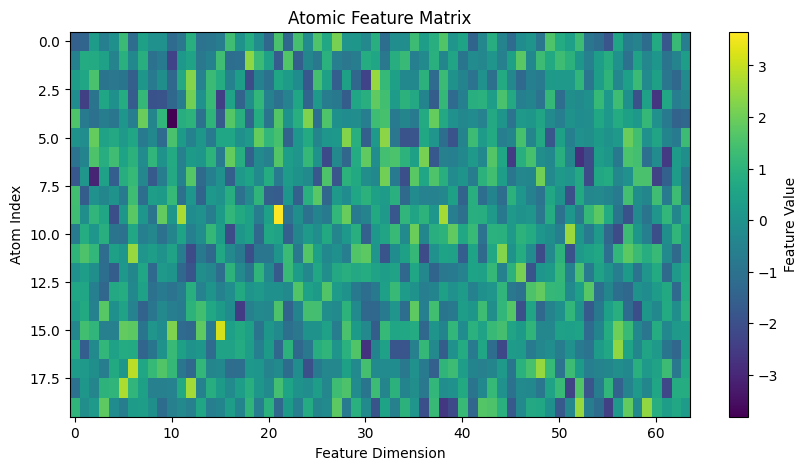

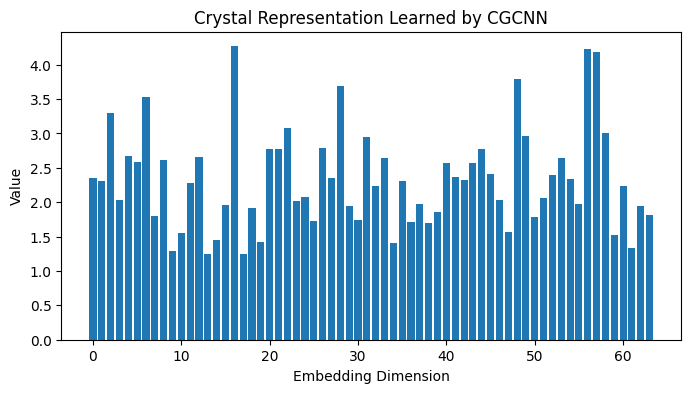

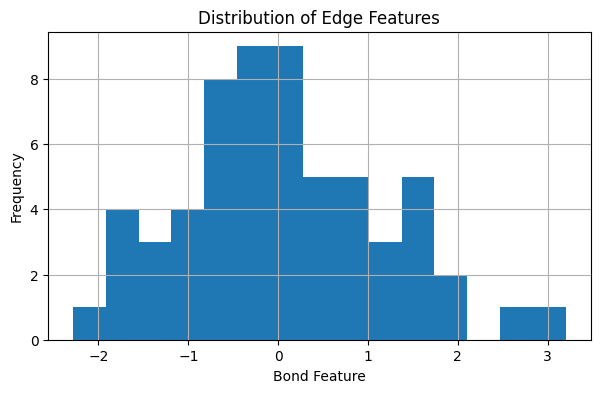

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch_geometric.nn import CGConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.data import Data

# --------------------------------------------------
# Crystal Graph CNN Model
# --------------------------------------------------
class CGCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = CGConv(
            channels=64,
            dim=1
        )

        self.conv2 = CGConv(
            channels=64,
            dim=1
        )

        self.fc = nn.Linear(
            64,
            1
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch
    ):

        x = self.conv1(
            x,
            edge_index,
            edge_attr
        )

        x = torch.relu(x)

        x = self.conv2(
            x,
            edge_index,
            edge_attr
        )

        x = torch.relu(x)

        crystal_embedding = global_mean_pool(
            x,
            batch
        )

        output = self.fc(
            crystal_embedding
        )

        return output, crystal_embedding

# --------------------------------------------------
# Create Synthetic Crystal Graph
# --------------------------------------------------
num_atoms = 20
num_edges = 60

graph = Data(
    x=torch.randn(num_atoms, 64),
    edge_index=torch.randint(
        0,
        num_atoms,
        (2, num_edges)
    ),
    edge_attr=torch.randn(
        num_edges,
        1
    ),
    batch=torch.zeros(
        num_atoms,
        dtype=torch.long
    )
)

# --------------------------------------------------
# Model Inference
# --------------------------------------------------
model = CGCNN()

with torch.no_grad():

    formation_energy, embedding = model(
        graph.x,
        graph.edge_index,
        graph.edge_attr,
        graph.batch
    )

energy = formation_energy.item()

print(
    f"Predicted Formation Energy: {energy:.4f} eV/atom"
)

# --------------------------------------------------
# Visualization 1
# Node Feature Heatmap
# --------------------------------------------------
plt.figure(figsize=(10,5))

plt.imshow(
    graph.x.numpy(),
    aspect="auto"
)

plt.colorbar(
    label="Feature Value"
)

plt.xlabel("Feature Dimension")
plt.ylabel("Atom Index")
plt.title("Atomic Feature Matrix")

plt.show()

# --------------------------------------------------
# Visualization 2
# Crystal Embedding
# --------------------------------------------------
plt.figure(figsize=(8,4))

plt.bar(
    range(len(embedding[0])),
    embedding[0].numpy()
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.title("Crystal Representation Learned by CGCNN")

plt.show()

# --------------------------------------------------
# Visualization 3
# Edge Feature Distribution
# --------------------------------------------------
plt.figure(figsize=(7,4))

plt.hist(
    graph.edge_attr.numpy(),
    bins=15
)

plt.xlabel("Bond Feature")
plt.ylabel("Frequency")
plt.title("Distribution of Edge Features")

plt.grid(True)

plt.show()

---

## 🧬 Use Case 6 — Conditional VAE (CVAE) for Novel Material Generation

<a id="use-case-6"></a>

| Field | Details |
|---|---|
| **Domain** | Materials Discovery / Generative Chemistry |
| **Use Case** | Generate novel materials conditioned on target properties using a Conditional Variational Autoencoder |
| **Problem Statement** | Inverse materials design asks: given a desired property (e.g. band gap = 2.0 eV), what material compositions should we explore? CVAEs learn a latent distribution over material representations conditioned on properties, enabling controlled generation. |
| **Role of This Code** | Implement a CVAE with property-conditioned encoder and decoder. Train on simulated material feature vectors. Generate new candidate materials by sampling from the conditioned latent space. Visualize latent space and reconstruction quality. |
| **Key Libraries** | `torch` `torch.nn` `matplotlib` |
| **Reference** | https://github.com/materialsproject/matminer |

## 🏗️ Architecture Diagram

```
Material Fingerprint x  [B × num_features]
Condition (property)  c  [B × 1]
        |
        ▼ (concat [x, c])
┌───────────────────────────────────┐
│  Encoder                          │
│  Linear(num_features+1 → 256)     │
│  ReLU                             │
│  Linear(256 → latent_dim × 2)     │  → μ, log σ²
└───────────────────────────────────┘
        |
        ▼ Reparameterization: z = μ + σ·ε
        |  (z conditioned on c)
        ▼ (concat [z, c])
┌───────────────────────────────────┐
│  Decoder                          │
│  Linear(latent_dim+1 → 256)       │
│  ReLU                             │
│  Linear(256 → num_features)       │  → reconstructed material
└───────────────────────────────────┘
        |
  ELBO Loss = Reconstruction + KL Divergence
```

Generated Material Feature Shape: torch.Size([1, 100])


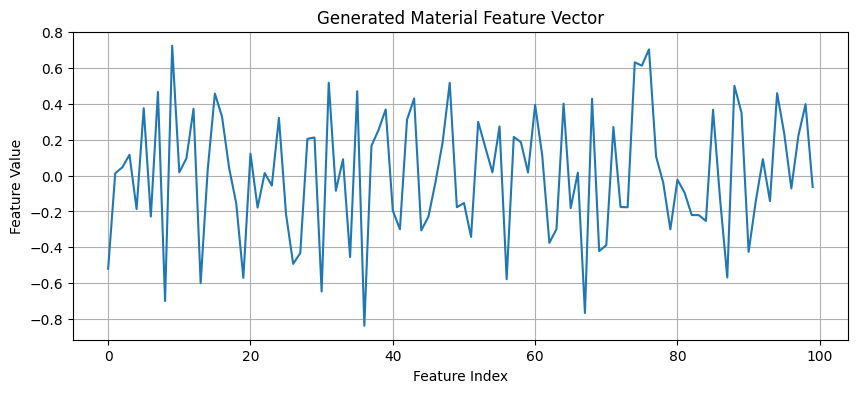

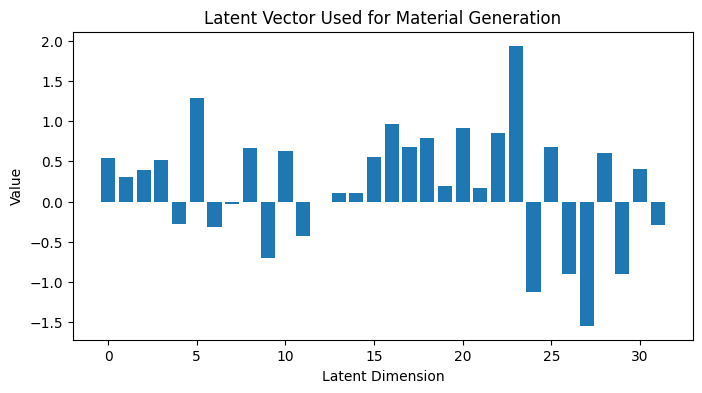

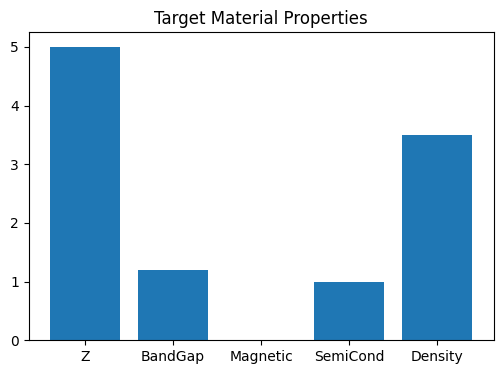

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --------------------------------------------------
# Conditional Variational Autoencoder
# --------------------------------------------------
class MatVAE(nn.Module):

    def __init__(
        self,
        num_features=100,
        latent_dim=32,
        num_conditions=5
    ):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(
                num_features + num_conditions,
                256
            ),
            nn.ReLU()
        )

        self.mu_layer = nn.Linear(
            256,
            latent_dim
        )

        self.logvar_layer = nn.Linear(
            256,
            latent_dim
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(
                latent_dim + num_conditions,
                256
            ),
            nn.ReLU(),
            nn.Linear(
                256,
                num_features
            )
        )

    # ----------------------------
    # Encode
    # ----------------------------
    def encode(self, x, c):

        h = self.encoder(
            torch.cat([x, c], dim=-1)
        )

        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)

        return mu, logvar

    # ----------------------------
    # Reparameterization
    # ----------------------------
    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std

    # ----------------------------
    # Decode
    # ----------------------------
    def decode(self, z, c):

        return self.decoder(
            torch.cat([z, c], dim=-1)
        )

    # ----------------------------
    # Forward
    # ----------------------------
    def forward(self, x, c):

        mu, logvar = self.encode(x, c)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstructed = self.decode(
            z,
            c
        )

        return reconstructed, mu, logvar

# --------------------------------------------------
# Create Model
# --------------------------------------------------
model = MatVAE()

# --------------------------------------------------
# Target Material Properties
# Example:
# [Atomic Number,
#  Band Gap,
#  Magnetic Flag,
#  Semiconductor Flag,
#  Density]
# --------------------------------------------------
condition = torch.tensor([
    [5.0, 1.2, 0.0, 1.0, 3.5]
])

# --------------------------------------------------
# Generate New Material
# --------------------------------------------------
z = torch.randn(1, 32)

with torch.no_grad():

    generated_material = model.decode(
        z,
        condition
    )

print(
    "Generated Material Feature Shape:",
    generated_material.shape
)

# --------------------------------------------------
# Visualization 1
# Generated Material Features
# --------------------------------------------------
plt.figure(figsize=(10,4))

plt.plot(
    generated_material[0].numpy()
)

plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.title("Generated Material Feature Vector")

plt.grid(True)

plt.show()

# --------------------------------------------------
# Visualization 2
# Latent Space Sample
# --------------------------------------------------
plt.figure(figsize=(8,4))

plt.bar(
    range(32),
    z[0].numpy()
)

plt.xlabel("Latent Dimension")
plt.ylabel("Value")
plt.title("Latent Vector Used for Material Generation")

plt.show()

# --------------------------------------------------
# Visualization 3
# Condition Values
# --------------------------------------------------
plt.figure(figsize=(6,4))

plt.bar(
    range(5),
    condition[0].numpy()
)

plt.xticks(
    range(5),
    [
        "Z",
        "BandGap",
        "Magnetic",
        "SemiCond",
        "Density"
    ]
)

plt.title("Target Material Properties")

plt.show()

---

## 📡 Use Case 7 — Graph Attention Network (GAT) for NMR Chemical Shift Prediction

<a id="use-case-7"></a>

| Field | Details |
|---|---|
| **Domain** | Computational Chemistry / Spectroscopy |
| **Use Case** | Predict NMR chemical shifts for each atom in a molecule using a Graph Attention Network |
| **Problem Statement** | NMR chemical shifts depend on the local electronic environment of each atom. Predicting shifts computationally accelerates structure elucidation, spectral assignment, and verification of synthetic products without requiring lab measurements. |
| **Role of This Code** | Build a 2-layer GATConv network over a molecular graph. Predict a scalar chemical shift for every atom. Visualize predicted shifts per atom, atomic feature heatmap, and shift distribution. |
| **Key Libraries** | `torch` `torch_geometric` `matplotlib` |
| **Reference** | https://github.com/jensengroup/nmrshiftdb |

## 🏗️ Architecture Diagram

```
Molecule SMILES
        |
        ▼ (featurize → graph)
  Molecular Graph
  • Nodes = atoms  (in_channels features)
  • Edges = bonds
        |
        ▼
┌──────────────────────────────────────┐
│  GATConv Layer 1                     │
│  Multi-head self-attention           │
│  in_channels → hidden_channels       │
│  heads × attention coefficients α_ij │
└──────────────────────────────────────┘
        |
        ▼
┌──────────────────────────────────────┐
│  GATConv Layer 2                     │
│  hidden_channels → hidden_channels   │
└──────────────────────────────────────┘
        |
        ▼
  Per-node Linear(hidden_channels → 1)
        |
  Chemical Shift (ppm) per atom  [N_atoms × 1]
```


Predicted NMR Chemical Shifts (ppm):
tensor([-0.0357, -0.0611, -0.0255, -0.0493, -0.0336])


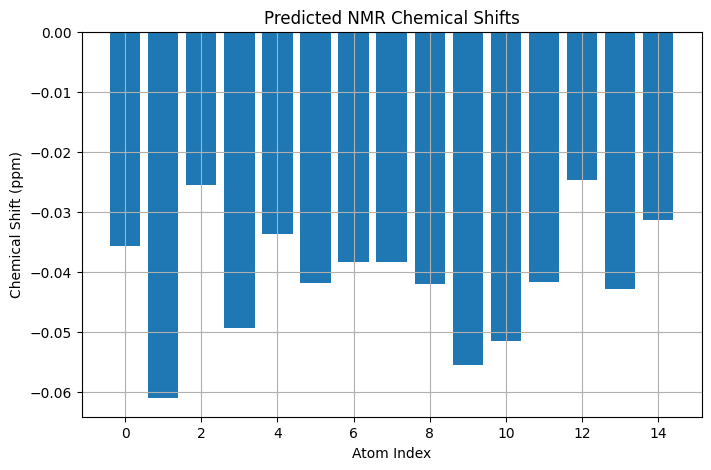

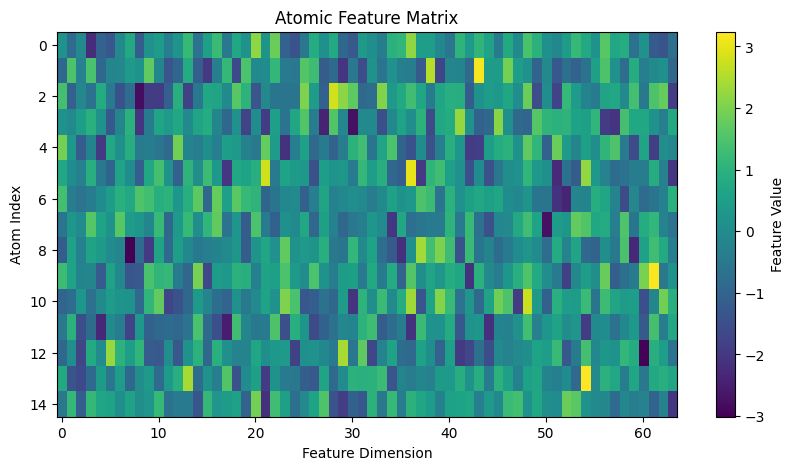

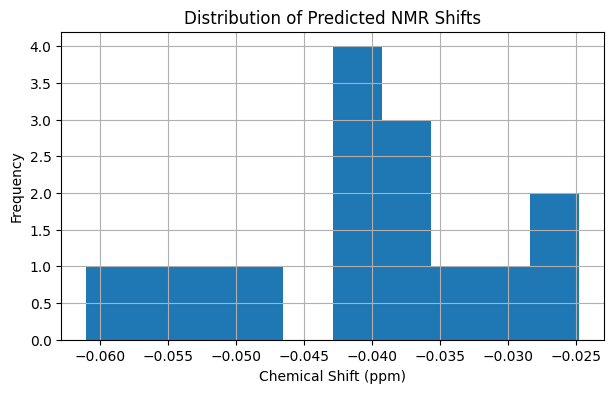

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch_geometric.nn import GATConv
from torch_geometric.data import Data

# --------------------------------------------------
# Graph Attention Network for NMR Prediction
# --------------------------------------------------
class NMRNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.gat1 = GATConv(
            in_channels=64,
            out_channels=64,
            heads=4,
            concat=False
        )

        self.gat2 = GATConv(
            in_channels=64,
            out_channels=64,
            heads=4,
            concat=False
        )

        self.fc = nn.Linear(
            64,
            1
        )

    def forward(self, x, edge_index):

        x = self.gat1(
            x,
            edge_index
        )

        x = torch.relu(x)

        x = self.gat2(
            x,
            edge_index
        )

        x = torch.relu(x)

        shifts = self.fc(x)

        return shifts

# --------------------------------------------------
# Create Synthetic Molecular Graph
# --------------------------------------------------
num_atoms = 15

graph = Data(
    x=torch.randn(num_atoms, 64),
    edge_index=torch.randint(
        0,
        num_atoms,
        (2, 40)
    )
)

# --------------------------------------------------
# Model Inference
# --------------------------------------------------
model = NMRNet()

with torch.no_grad():

    predicted_shifts = model(
        graph.x,
        graph.edge_index
    )

predicted_shifts = predicted_shifts.squeeze()

print("\nPredicted NMR Chemical Shifts (ppm):")
print(predicted_shifts[:5])

# --------------------------------------------------
# Visualization 1
# Predicted NMR Shifts
# --------------------------------------------------
plt.figure(figsize=(8,5))

plt.bar(
    range(num_atoms),
    predicted_shifts.numpy()
)

plt.xlabel("Atom Index")
plt.ylabel("Chemical Shift (ppm)")
plt.title("Predicted NMR Chemical Shifts")

plt.grid(True)

plt.show()

# --------------------------------------------------
# Visualization 2
# Atomic Feature Heatmap
# --------------------------------------------------
plt.figure(figsize=(10,5))

plt.imshow(
    graph.x.numpy(),
    aspect="auto"
)

plt.colorbar(
    label="Feature Value"
)

plt.xlabel("Feature Dimension")
plt.ylabel("Atom Index")
plt.title("Atomic Feature Matrix")

plt.show()

# --------------------------------------------------
# Visualization 3
# Shift Distribution
# --------------------------------------------------
plt.figure(figsize=(7,4))

plt.hist(
    predicted_shifts.numpy(),
    bins=10
)

plt.xlabel("Chemical Shift (ppm)")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted NMR Shifts")

plt.grid(True)

plt.show()